#GAN
In this notebook is implemented a GAN that learns to produce realistic-looking
handwritten digits.

It will be use the Python neural network library Keras with a
TensorFlow backend.

Python 3.6.0, Keras 2.1.6, and TensorFlow 1.8.0.

In [ ]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np

from keras.datasets import mnist

from keras.layers import Dense, Flatten, Reshape
from keras.layers import LeakyReLU
from keras.models import Sequential
from keras.optimizers import Adam

We specify the input dimensions of our model and dataset. Each image in
MNIST is 28 × 28 pixels with a single channel (because the images are grayscale)

In [ ]:
img_rows = 28
img_cols = 28
channels = 1

# Input image dimensions
img_shape = (img_rows, img_cols, channels)

# Size of the noise vector, used as input to the Generator
z_dim = 100 

#Generator
It
takes in z as input and produces a 28 × 28 × 1 image.

In [ ]:
def build_generator(img_shape, z_dim):

 model = Sequential()
 
 # Fully connected layer
 model.add(Dense(128, input_dim=z_dim))

 # Leaky ReLU activation (unique hidden layer)
 model.add(LeakyReLU(alpha=0.01))

 # Output layer with tanh activation
 model.add(Dense(28 * 28 * 1, activation='tanh'))

 # Reshape the Generator output to image dimensions
 model.add(Reshape(img_shape))
 return model

#Discriminator
The Discriminator takes in a 28 × 28 × 1 image and outputs a probability indicating
whether the input is deemed real rather than fake.

Two layer NN

In [ ]:
def build_discriminator(img_shape):

 model = Sequential()

 # Flatten the input image
 model.add(Flatten(input_shape=img_shape))

 # Fully connected layer (hidden units = 128)
 model.add(Dense(128))

 # Leaky ReLU activation of the hidden layer
 model.add(LeakyReLU(alpha=0.01))

 # Output layer with sigmoid activation
 model.add(Dense(1, activation='sigmoid')) #ensures probability between 0 and 1

 return model

#Build the Model

In [ ]:
def build_gan(generator, discriminator):

 model = Sequential()

 #Combined Generator/Discriminator model
 model.add(generator)
 model.add(discriminator)
 
 return model

In [ ]:
# Build and compile the Discriminator
discriminator = build_discriminator(img_shape)
discriminator.compile(loss='binary_crossentropy',
                      optimizer=Adam(),metrics=['accuracy'])

# Build the Generator
generator = build_generator(img_shape, z_dim)

# Keep Discriminator’s parameters constant for Generator training 
discriminator.trainable = False

# Build and compile GAN model with fixed Discriminator to train the Generator
gan = build_gan(generator, discriminator)
gan.compile(loss='binary_crossentropy', optimizer=Adam())

#Outputting sample images

In [ ]:
def sample_images(generator, image_grid_rows=4, image_grid_columns=4):

  # Sample random noise (standard normal distribution 0 mean and 1 std dev)
  z = np.random.normal(0, 1, (image_grid_rows * image_grid_columns, z_dim))
  
  # Generate images from random noise
  gen_imgs = generator.predict(z)

  # Rescale image pixel values to [0, 1] 
  gen_imgs = 0.5 * gen_imgs + 0.5

   # Set image grid
  fig, axs = plt.subplots(image_grid_rows,
  image_grid_columns,
  figsize=(4, 4),
  sharey=True,
  sharex=True)

  cnt = 0
  for i in range(image_grid_rows):
    for j in range(image_grid_columns):
      # Output a grid of images
      axs[i, j].imshow(gen_imgs[cnt, :, :, 0], cmap='gray')
      axs[i, j].axis('off')
      cnt += 1

#Training

In [ ]:
losses = []
accuracies = []
iteration_checkpoints = []

def train(iterations, batch_size, sample_interval):

  # Load the MNIST dataset (60000 images)
  (X_train, _), (_, _) = mnist.load_data()

  # Rescale [0, 255] grayscale pixel values to [-1, 1]
  X_train = X_train / 127.5 - 1.0
  X_train = np.expand_dims(X_train, axis=3)

  # Labels for real images: all ones
  real = np.ones((batch_size, 1))

  # Labels for fake images: all zeros
  fake = np.zeros((batch_size, 1))
  

  for iteration in range(iterations):

    # -------------------------
    #  Train the Discriminator
    # -------------------------

    # Get a random batch of real images
    idx = np.random.randint(0, X_train.shape[0], batch_size)
    imgs = X_train[idx]

    # Generate a batch of fake images
    z = np.random.normal(0, 1, (batch_size, 100))
    gen_imgs = generator.predict(z)

    # Train Discriminator
    d_loss_real = discriminator.train_on_batch(imgs, real)
    d_loss_fake = discriminator.train_on_batch(gen_imgs, fake)
    d_loss, accuracy = 0.5 * np.add(d_loss_real, d_loss_fake)

    # ---------------------
    #  Train the Generator
    # ---------------------
    
    # Generate a batch of fake images
    z = np.random.normal(0, 1, (batch_size, 100))
    gen_imgs = generator.predict(z)

    # Train Generator
    g_loss = gan.train_on_batch(z, real)

    if (iteration + 1) % sample_interval == 0:

      # Save losses and accuracies so they can be plotted after training
      losses.append((d_loss, g_loss))
      accuracies.append(100.0 * accuracy)
      iteration_checkpoints.append(iteration + 1)

      # Output training progress
      print("%d [D loss: %f, acc.: %.2f%%] [G loss: %f]" %
      (iteration + 1, d_loss, 100.0 * accuracy, g_loss))

      # Output a sample of generated image
      sample_images(generator)

#Train the GAN and inspect Output

Se han truncado las últimas 5000 líneas del flujo de salida.
4/4 [==============================] - 0s 5ms/step
18000 [D loss: 0.404446, acc.: 80.08%] [G loss: 2.753350]
4/4 [==============================] - 0s 4ms/step
19000 [D loss: 0.426119, acc.: 78.12%] [G loss: 2.266125]
4/4 [==============================] - 0s 5ms/step
20000 [D loss: 0.432017, acc.: 78.91%] [G loss: 2.633547]
1/1 [==============================] - 0s 22ms/step


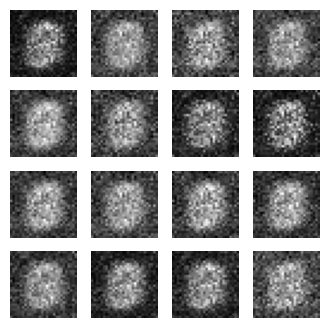

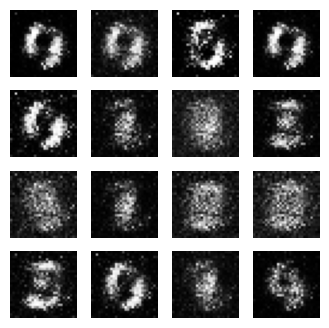

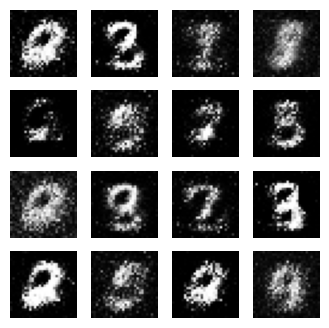

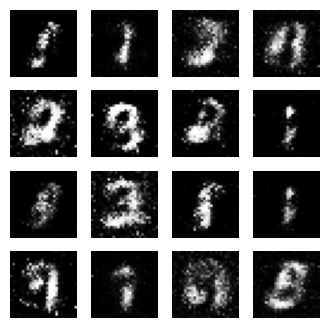

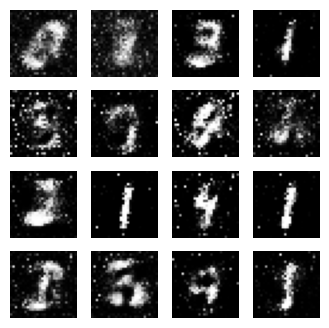

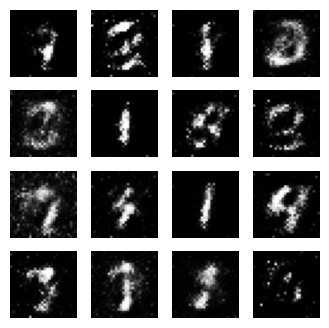

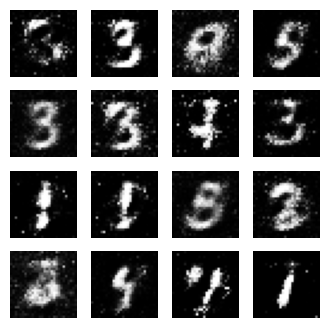

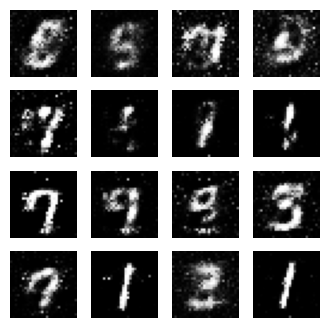

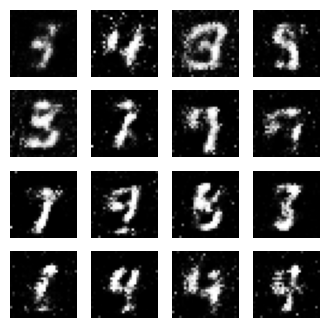

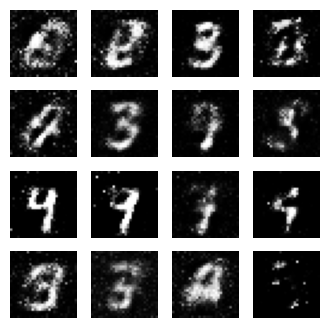

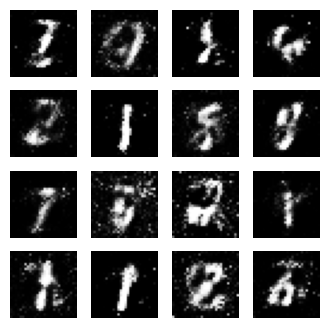

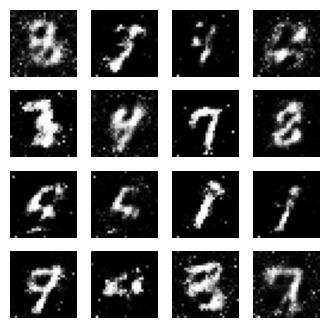

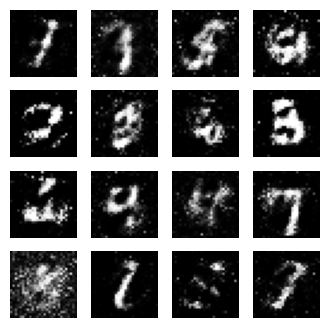

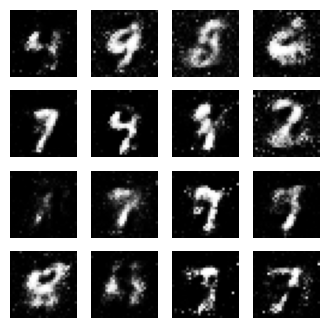

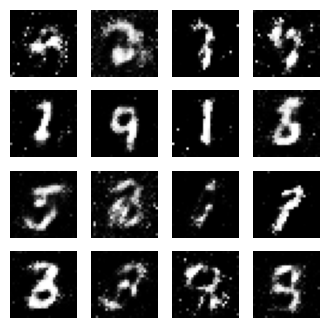

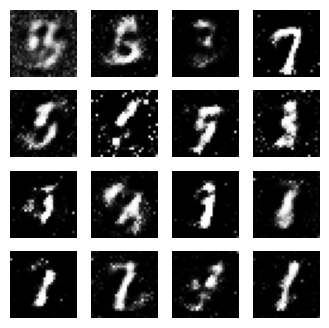

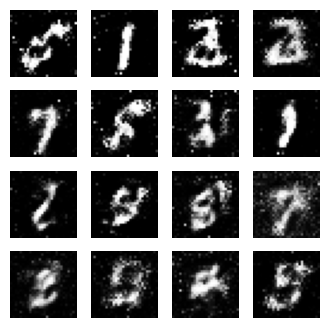

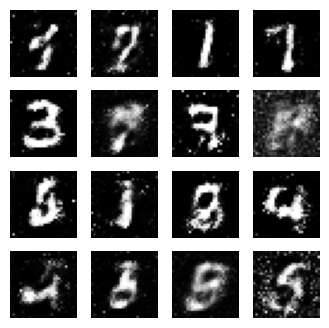

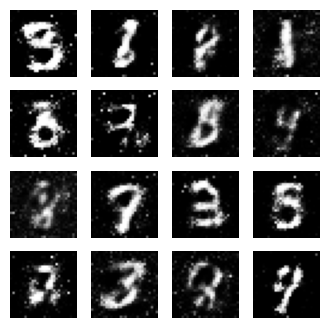

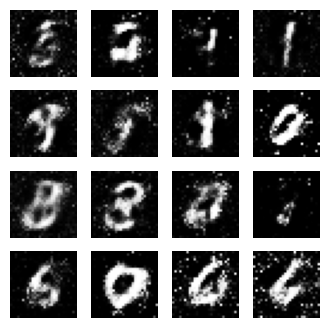

In [ ]:
# Set hyperparameters
iterations = 20000
batch_size = 128
sample_interval = 1000

# Train the GAN for the specified number of iterations
train(iterations, batch_size, sample_interval)